# Electricity Trustworthiness Synthesis

## Role
This notebook synthesizes the already-separated Electricity evidence dimensions --
Accuracy, Regime-Conditional Robustness, Temporal Stability, Uncertainty Calibration,
and Transparency/Auditability/Reproducibility -- into a dimension-first trustworthiness
summary, and reports the frozen exploratory composite Trust Score alongside them. It
carries forward the Accuracy Evidence and Computational/Reproducibility Evidence
previously part of `15_Electricity_Trustworthiness_Evidence.ipynb`, together with the
Trust Score synthesis previously in `16_Electricity_Trustworthiness.ipynb`.

## Inputs
The frozen authoritative forecast matrices, the frozen regime/temporal-segment metrics
artifacts, the frozen uncertainty evidence artifact, and the frozen
`protocol_a/b_trust_scores.csv` and `trust_score_sensitivity.csv` artifacts.

## Outputs
Dimension-level component evidence tables and an exploratory composite Trustworthiness
Summary (both Missing-Evidence-Penalised and Evidence-Available variants), plus a
validation/audit table local to this synthesis.

## Depends On
`14_Electricity_Model_Validation_Audit.ipynb`, `15_Electricity_Robustness.ipynb`,
`16_Electricity_Uncertainty.ipynb`

## Authoritative Status
`AUTHORITATIVE SYNTHESIS; COMPOSITE IS SECONDARY`

## What This Notebook Does Not Do
This notebook does NOT:
- calculate regimes or temporal segments (`15_Electricity_Robustness.ipynb` is authoritative)
- calibrate or evaluate uncertainty evidence (`16_Electricity_Uncertainty.ipynb` is authoritative)
- perform statistical-significance testing (`18_Electricity_Statistical_Significance.ipynb`)
- train, fit, or refit any model

## 1. Objective

This notebook synthesizes multiple evidence dimensions rather than treating predictive
accuracy as synonymous with trustworthiness. The primary interpretation is
**dimension-level** -- Section 4 below reports each evidence dimension on its own terms.

The composite **Exploratory Composite Trustworthiness Summary** (Section 5) is:

> EXPLORATORY. SECONDARY. RESEARCHER-DEFINED.

It is **not** a validated measurement instrument, and it is not the sole conclusion of
this notebook.

## 2. Setup

Loads the frozen artifacts already used by the two notebooks this one synthesizes. No
upstream evidence is regenerated, and no model is fit or refit.

In [1]:
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "src").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate project root containing src/")

ROOT = find_project_root(Path.cwd())
R = ROOT / "results/electricity"
SCALE = 117.057971280678

pa = pd.read_csv(R / "protocol_a_validated_forecasts.csv", parse_dates=["Timestamp"])
pb = pd.read_csv(R / "protocol_b_validated_forecasts.csv", parse_dates=["Origin", "Timestamp"])
MODELS = ["Naive", "Daily_Seasonal_Naive", "Weekly_Seasonal_Naive", "Moving_Average", "ARIMA", "SARIMA",
          "Prophet", "Simple_Exponential_Smoothing", "Holt_Winters", "DHR_ARIMA", "LSTM", "Chronos_Bolt_Tiny", "TimesFM"]
assert pa.shape == (46176, 15) and pb.shape == (46176, 17)

robust_a = pd.read_csv(R / "protocol_a_robustness.csv")
robust_b = pd.read_csv(R / "protocol_b_robustness.csv")
temporal_a = pd.read_csv(R / "protocol_a_generalisation.csv", parse_dates=["Start", "End"])
temporal_b = pd.read_csv(R / "protocol_b_generalisation.csv", parse_dates=["Start", "End"])
uncertainty = pd.read_csv(R / "uncertainty_summary.csv")

trust_a = pd.read_csv(R / "protocol_a_trust_scores.csv")
trust_b = pd.read_csv(R / "protocol_b_trust_scores.csv")
sensitivity = pd.read_csv(R / "trust_score_sensitivity.csv")

## 3. Data and Method

### 3.1 Accuracy Evidence

Recovered from `15_Electricity_Trustworthiness_Evidence.ipynb`'s own Accuracy Evidence
computation (same formula, same frozen `pa`/`pb` inputs) -- this is a cheap,
deterministic recomputation from already-loaded frozen data, not a new experiment.

In [2]:
def metrics(a, p):
    a = np.asarray(a, float); p = np.asarray(p, float); e = a - p
    return {"MAE": np.mean(abs(e)), "RMSE": np.sqrt(np.mean(e ** 2)), "MAPE": np.mean(abs(e / a)) * 100,
            "sMAPE": np.mean(2 * abs(e) / (abs(a) + abs(p))) * 100, "MASE_48": np.mean(abs(e)) / SCALE}

accuracy_rows = []
for protocol, frame in [("A", pa), ("B", pb)]:
    rows = [{"Protocol": protocol, "Model": m, **metrics(frame.Actual, frame[m])} for m in MODELS]
    best = min(x["MASE_48"] for x in rows)
    for x in rows:
        x["Relative_Accuracy_Score"] = np.clip(100 * best / x["MASE_48"], 0, 100)
    accuracy_rows.extend(rows)
accuracy = pd.DataFrame(accuracy_rows)

### 3.2 Regime-Conditional Robustness Evidence

Uses the same frozen `protocol_a/b_robustness.csv` evidence `15_Electricity_Robustness.ipynb`
is authoritative for.

### 3.3 Temporal Stability Evidence

Uses the same frozen `protocol_a/b_generalisation.csv` evidence `15_Electricity_Robustness.ipynb`
is authoritative for (stored artifact filenames retain the historical `generalisation`
name; this notebook uses **Temporal Stability** in its own prose).

### 3.4 Uncertainty Calibration Evidence

Uses the same frozen `uncertainty_summary.csv` evidence `16_Electricity_Uncertainty.ipynb`
is authoritative for.

### 3.5 Transparency, Auditability, and Reproducibility Evidence

Recovered verbatim from `15_Electricity_Trustworthiness_Evidence.ipynb`'s Computational /
Reproducibility Evidence table and `16_Electricity_Trustworthiness.ipynb`'s Explainability
and Reproducibility table -- both are carried forward as the same frozen literal
evidence, not recomputed or re-scored.

In [3]:
computational = pd.DataFrame([{'Model': 'Naive', 'Protocol': 'A', 'Model_Type': 'Deterministic baseline', 'Task_Specific_Training': False, 'Zero_Shot': False, 'Approx_Training_Cost': 'None', 'Approx_Inference_Cost': 'Vector operation; exact runtime unavailable', 'Deterministic_Reproducible': True, 'Failure_Detectability': 'Saved vectors + finite/alignment/distribution audit', 'Artifact_Saved': True, 'Protocol_Audit_Passed': True}, {'Model': 'Daily_Seasonal_Naive', 'Protocol': 'A', 'Model_Type': 'Deterministic baseline', 'Task_Specific_Training': False, 'Zero_Shot': False, 'Approx_Training_Cost': 'None', 'Approx_Inference_Cost': 'Vector operation; exact runtime unavailable', 'Deterministic_Reproducible': True, 'Failure_Detectability': 'Saved vectors + finite/alignment/distribution audit', 'Artifact_Saved': True, 'Protocol_Audit_Passed': True}, {'Model': 'Weekly_Seasonal_Naive', 'Protocol': 'A', 'Model_Type': 'Deterministic baseline', 'Task_Specific_Training': False, 'Zero_Shot': False, 'Approx_Training_Cost': 'None', 'Approx_Inference_Cost': 'Vector operation; exact runtime unavailable', 'Deterministic_Reproducible': True, 'Failure_Detectability': 'Saved vectors + finite/alignment/distribution audit', 'Artifact_Saved': True, 'Protocol_Audit_Passed': True}, {'Model': 'Moving_Average', 'Protocol': 'A', 'Model_Type': 'Deterministic baseline', 'Task_Specific_Training': False, 'Zero_Shot': False, 'Approx_Training_Cost': 'Validation-only window selection', 'Approx_Inference_Cost': 'Vector operation; exact runtime unavailable', 'Deterministic_Reproducible': True, 'Failure_Detectability': 'Saved vectors + finite/alignment/distribution audit', 'Artifact_Saved': True, 'Protocol_Audit_Passed': True}, {'Model': 'DHR_ARIMA', 'Protocol': 'A', 'Model_Type': 'Statistical', 'Task_Specific_Training': True, 'Zero_Shot': False, 'Approx_Training_Cost': 'Selection 484.97 s; final fit 19.12 s', 'Approx_Inference_Cost': '0.117 s', 'Deterministic_Reproducible': True, 'Failure_Detectability': 'Saved vectors + finite/alignment/distribution audit', 'Artifact_Saved': True, 'Protocol_Audit_Passed': True}, {'Model': 'LSTM', 'Protocol': 'A', 'Model_Type': 'Neural', 'Task_Specific_Training': True, 'Zero_Shot': False, 'Approx_Training_Cost': 'Measured total including selection 2239.91 s', 'Approx_Inference_Cost': '8.055 s', 'Deterministic_Reproducible': True, 'Failure_Detectability': 'Saved vectors + finite/alignment/distribution audit', 'Artifact_Saved': True, 'Protocol_Audit_Passed': True}, {'Model': 'Chronos_Bolt_Tiny', 'Protocol': 'A', 'Model_Type': 'Foundation', 'Task_Specific_Training': False, 'Zero_Shot': True, 'Approx_Training_Cost': 'None', 'Approx_Inference_Cost': 'Measured but exact uninterrupted total not retained', 'Deterministic_Reproducible': True, 'Failure_Detectability': 'Saved vectors + finite/alignment/distribution audit', 'Artifact_Saved': True, 'Protocol_Audit_Passed': True}, {'Model': 'TimesFM', 'Protocol': 'A', 'Model_Type': 'Foundation', 'Task_Specific_Training': False, 'Zero_Shot': True, 'Approx_Training_Cost': 'None', 'Approx_Inference_Cost': 'Approximately 51 min CPU (checkpoint wall time)', 'Deterministic_Reproducible': True, 'Failure_Detectability': 'Saved vectors + finite/alignment/distribution audit', 'Artifact_Saved': True, 'Protocol_Audit_Passed': True}, {'Model': 'Naive', 'Protocol': 'B', 'Model_Type': 'Deterministic baseline', 'Task_Specific_Training': False, 'Zero_Shot': False, 'Approx_Training_Cost': 'None', 'Approx_Inference_Cost': 'Vector operation; exact runtime unavailable', 'Deterministic_Reproducible': True, 'Failure_Detectability': 'Saved vectors + finite/alignment/distribution audit', 'Artifact_Saved': True, 'Protocol_Audit_Passed': True}, {'Model': 'Daily_Seasonal_Naive', 'Protocol': 'B', 'Model_Type': 'Deterministic baseline', 'Task_Specific_Training': False, 'Zero_Shot': False, 'Approx_Training_Cost': 'None', 'Approx_Inference_Cost': 'Vector operation; exact runtime unavailable', 'Deterministic_Reproducible': True, 'Failure_Detectability': 'Saved vectors + finite/alignment/distribution audit', 'Artifact_Saved': True, 'Protocol_Audit_Passed': True}, {'Model': 'Weekly_Seasonal_Naive', 'Protocol': 'B', 'Model_Type': 'Deterministic baseline', 'Task_Specific_Training': False, 'Zero_Shot': False, 'Approx_Training_Cost': 'None', 'Approx_Inference_Cost': 'Vector operation; exact runtime unavailable', 'Deterministic_Reproducible': True, 'Failure_Detectability': 'Saved vectors + finite/alignment/distribution audit', 'Artifact_Saved': True, 'Protocol_Audit_Passed': True}, {'Model': 'Moving_Average', 'Protocol': 'B', 'Model_Type': 'Deterministic baseline', 'Task_Specific_Training': False, 'Zero_Shot': False, 'Approx_Training_Cost': 'Validation-only window selection', 'Approx_Inference_Cost': 'Recursive vector operation; exact runtime unavailable', 'Deterministic_Reproducible': True, 'Failure_Detectability': 'Saved vectors + finite/alignment/distribution audit', 'Artifact_Saved': True, 'Protocol_Audit_Passed': True}, {'Model': 'DHR_ARIMA', 'Protocol': 'B', 'Model_Type': 'Statistical', 'Task_Specific_Training': True, 'Zero_Shot': False, 'Approx_Training_Cost': 'Selection 484.97 s; final fit 19.12 s', 'Approx_Inference_Cost': '1.019 s', 'Deterministic_Reproducible': True, 'Failure_Detectability': 'Saved vectors + finite/alignment/distribution audit', 'Artifact_Saved': True, 'Protocol_Audit_Passed': True}, {'Model': 'LSTM', 'Protocol': 'B', 'Model_Type': 'Neural', 'Task_Specific_Training': True, 'Zero_Shot': False, 'Approx_Training_Cost': 'Measured total including selection 2239.91 s', 'Approx_Inference_Cost': '0.632 s', 'Deterministic_Reproducible': True, 'Failure_Detectability': 'Saved vectors + finite/alignment/distribution audit', 'Artifact_Saved': True, 'Protocol_Audit_Passed': True}, {'Model': 'Chronos_Bolt_Tiny', 'Protocol': 'B', 'Model_Type': 'Foundation', 'Task_Specific_Training': False, 'Zero_Shot': True, 'Approx_Training_Cost': 'None', 'Approx_Inference_Cost': '1.623 s', 'Deterministic_Reproducible': True, 'Failure_Detectability': 'Saved vectors + finite/alignment/distribution audit', 'Artifact_Saved': True, 'Protocol_Audit_Passed': True}, {'Model': 'TimesFM', 'Protocol': 'B', 'Model_Type': 'Foundation', 'Task_Specific_Training': False, 'Zero_Shot': True, 'Approx_Training_Cost': 'None', 'Approx_Inference_Cost': '68.292 s', 'Deterministic_Reproducible': True, 'Failure_Detectability': 'Saved vectors + finite/alignment/distribution audit', 'Artifact_Saved': True, 'Protocol_Audit_Passed': True}, {'Model': 'ARIMA', 'Protocol': 'A', 'Model_Type': 'Statistical', 'Task_Specific_Training': True, 'Zero_Shot': False, 'Approx_Training_Cost': '~65 s (selection + sequential fixed-parameter state fit/forecast, combined; measured via generator-run file timestamps)', 'Approx_Inference_Cost': 'Included in the combined selection+fit+forecast measurement (Protocol A and B are produced together, not separately timed)', 'Deterministic_Reproducible': True, 'Failure_Detectability': 'Saved vectors + finite/alignment/distribution audit', 'Artifact_Saved': True, 'Protocol_Audit_Passed': True}, {'Model': 'ARIMA', 'Protocol': 'B', 'Model_Type': 'Statistical', 'Task_Specific_Training': True, 'Zero_Shot': False, 'Approx_Training_Cost': '~65 s (selection + sequential fixed-parameter state fit/forecast, combined; measured via generator-run file timestamps)', 'Approx_Inference_Cost': 'Included in the combined selection+fit+forecast measurement (Protocol A and B are produced together, not separately timed)', 'Deterministic_Reproducible': True, 'Failure_Detectability': 'Saved vectors + finite/alignment/distribution audit', 'Artifact_Saved': True, 'Protocol_Audit_Passed': True}, {'Model': 'SARIMA', 'Protocol': 'A', 'Model_Type': 'Statistical', 'Task_Specific_Training': True, 'Zero_Shot': False, 'Approx_Training_Cost': '~50 s (selection + sequential fixed-parameter state fit/forecast, combined; measured via generator-run file timestamps)', 'Approx_Inference_Cost': 'Included in the combined selection+fit+forecast measurement (Protocol A and B are produced together, not separately timed)', 'Deterministic_Reproducible': True, 'Failure_Detectability': 'Saved vectors + finite/alignment/distribution audit', 'Artifact_Saved': True, 'Protocol_Audit_Passed': True}, {'Model': 'SARIMA', 'Protocol': 'B', 'Model_Type': 'Statistical', 'Task_Specific_Training': True, 'Zero_Shot': False, 'Approx_Training_Cost': '~50 s (selection + sequential fixed-parameter state fit/forecast, combined; measured via generator-run file timestamps)', 'Approx_Inference_Cost': 'Included in the combined selection+fit+forecast measurement (Protocol A and B are produced together, not separately timed)', 'Deterministic_Reproducible': True, 'Failure_Detectability': 'Saved vectors + finite/alignment/distribution audit', 'Artifact_Saved': True, 'Protocol_Audit_Passed': True}, {'Model': 'Prophet', 'Protocol': 'A', 'Model_Type': 'Statistical', 'Task_Specific_Training': True, 'Zero_Shot': False, 'Approx_Training_Cost': '~712 s (~11.9 min): 11 validation-selection refits + up to 69 periodic refits over the test period (cmdstanpy backend)', 'Approx_Inference_Cost': 'Included in the combined selection+fit+forecast measurement (Protocol A and B are produced together, not separately timed)', 'Deterministic_Reproducible': True, 'Failure_Detectability': 'Saved vectors + finite/alignment/distribution audit', 'Artifact_Saved': True, 'Protocol_Audit_Passed': True}, {'Model': 'Prophet', 'Protocol': 'B', 'Model_Type': 'Statistical', 'Task_Specific_Training': True, 'Zero_Shot': False, 'Approx_Training_Cost': '~712 s (~11.9 min): 11 validation-selection refits + up to 69 periodic refits over the test period (cmdstanpy backend)', 'Approx_Inference_Cost': 'Included in the combined selection+fit+forecast measurement (Protocol A and B are produced together, not separately timed)', 'Deterministic_Reproducible': True, 'Failure_Detectability': 'Saved vectors + finite/alignment/distribution audit', 'Artifact_Saved': True, 'Protocol_Audit_Passed': True}, {'Model': 'Simple_Exponential_Smoothing', 'Protocol': 'A', 'Model_Type': 'Statistical', 'Task_Specific_Training': True, 'Zero_Shot': False, 'Approx_Training_Cost': '~59 s: 162 validation-selection refits + 962 periodic refits (each fit sub-second)', 'Approx_Inference_Cost': 'Included in the combined selection+fit+forecast measurement (Protocol A and B are produced together, not separately timed)', 'Deterministic_Reproducible': True, 'Failure_Detectability': 'Saved vectors + finite/alignment/distribution audit', 'Artifact_Saved': True, 'Protocol_Audit_Passed': True}, {'Model': 'Simple_Exponential_Smoothing', 'Protocol': 'B', 'Model_Type': 'Statistical', 'Task_Specific_Training': True, 'Zero_Shot': False, 'Approx_Training_Cost': '~59 s: 162 validation-selection refits + 962 periodic refits (each fit sub-second)', 'Approx_Inference_Cost': 'Included in the combined selection+fit+forecast measurement (Protocol A and B are produced together, not separately timed)', 'Deterministic_Reproducible': True, 'Failure_Detectability': 'Saved vectors + finite/alignment/distribution audit', 'Artifact_Saved': True, 'Protocol_Audit_Passed': True}, {'Model': 'Holt_Winters', 'Protocol': 'A', 'Model_Type': 'Statistical', 'Task_Specific_Training': True, 'Zero_Shot': False, 'Approx_Training_Cost': '~431 s (~7.2 min): 11 validation-selection refits + up to 69 periodic refits (damped-trend ETS)', 'Approx_Inference_Cost': 'Included in the combined selection+fit+forecast measurement (Protocol A and B are produced together, not separately timed)', 'Deterministic_Reproducible': True, 'Failure_Detectability': 'Saved vectors + finite/alignment/distribution audit', 'Artifact_Saved': True, 'Protocol_Audit_Passed': True}, {'Model': 'Holt_Winters', 'Protocol': 'B', 'Model_Type': 'Statistical', 'Task_Specific_Training': True, 'Zero_Shot': False, 'Approx_Training_Cost': '~431 s (~7.2 min): 11 validation-selection refits + up to 69 periodic refits (damped-trend ETS)', 'Approx_Inference_Cost': 'Included in the combined selection+fit+forecast measurement (Protocol A and B are produced together, not separately timed)', 'Deterministic_Reproducible': True, 'Failure_Detectability': 'Saved vectors + finite/alignment/distribution audit', 'Artifact_Saved': True, 'Protocol_Audit_Passed': True}])

explainability = pd.DataFrame([{'Model': 'Naive', 'Model Transparency': 100, 'Ease of Interpretation': 100, 'Computational Complexity': 100, 'Reproducibility': 100, 'Failure Detectability': 95, 'Reason': 'Single lag-1 rule; fully auditable vector.', 'Explainability Score': 99.0}, {'Model': 'Daily_Seasonal_Naive', 'Model Transparency': 100, 'Ease of Interpretation': 100, 'Computational Complexity': 100, 'Reproducibility': 100, 'Failure Detectability': 95, 'Reason': 'Fixed lag-48 seasonal rule; fully auditable.', 'Explainability Score': 99.0}, {'Model': 'Weekly_Seasonal_Naive', 'Model Transparency': 100, 'Ease of Interpretation': 100, 'Computational Complexity': 100, 'Reproducibility': 100, 'Failure Detectability': 95, 'Reason': 'Fixed lag-336 seasonal rule; fully auditable.', 'Explainability Score': 99.0}, {'Model': 'Moving_Average', 'Model Transparency': 95, 'Ease of Interpretation': 95, 'Computational Complexity': 100, 'Reproducibility': 100, 'Failure Detectability': 90, 'Reason': 'Explicit 48-point averaging rule; Protocol B recursion remains inspectable.', 'Explainability Score': 96.0}, {'Model': 'DHR_ARIMA', 'Model Transparency': 75, 'Ease of Interpretation': 80, 'Computational Complexity': 65, 'Reproducibility': 90, 'Failure Detectability': 85, 'Reason': 'Fourier terms and AR errors are interpretable; fitting and state logic add complexity.', 'Explainability Score': 79.0}, {'Model': 'LSTM', 'Model Transparency': 45, 'Ease of Interpretation': 50, 'Computational Complexity': 45, 'Reproducibility': 75, 'Failure Detectability': 70, 'Reason': 'Deterministic training is documented, but learned recurrent representation is opaque.', 'Explainability Score': 57.0}, {'Model': 'Chronos_Bolt_Tiny', 'Model Transparency': 30, 'Ease of Interpretation': 40, 'Computational Complexity': 75, 'Reproducibility': 90, 'Failure Detectability': 80, 'Reason': 'Opaque pretrained model; zero-shot saved-vector workflow is reproducible and auditable.', 'Explainability Score': 63.0}, {'Model': 'TimesFM', 'Model Transparency': 35, 'Ease of Interpretation': 45, 'Computational Complexity': 90, 'Reproducibility': 90, 'Failure Detectability': 85, 'Reason': 'Opaque pretrained model; zero-shot interface and strong artifact diagnostics aid reproduction.', 'Explainability Score': 69.0}, {'Model': 'ARIMA', 'Model Transparency': 82, 'Ease of Interpretation': 85, 'Computational Complexity': 72, 'Reproducibility': 92, 'Failure Detectability': 85, 'Reason': 'Fixed-order univariate ARIMA; sequential state extension is fully inspectable.', 'Explainability Score': 83.2}, {'Model': 'SARIMA', 'Model Transparency': 75, 'Ease of Interpretation': 78, 'Computational Complexity': 55, 'Reproducibility': 90, 'Failure Detectability': 85, 'Reason': 'Seasonal state space is heavier than plain ARIMA but the fixed order remains interpretable.', 'Explainability Score': 76.6}, {'Model': 'Prophet', 'Model Transparency': 70, 'Ease of Interpretation': 75, 'Computational Complexity': 60, 'Reproducibility': 85, 'Failure Detectability': 80, 'Reason': 'Additive trend/seasonality decomposition is inspectable; periodic-refit cadence is an explicit, validation-selected approximation.', 'Explainability Score': 74.0}, {'Model': 'Simple_Exponential_Smoothing', 'Model Transparency': 95, 'Ease of Interpretation': 95, 'Computational Complexity': 95, 'Reproducibility': 95, 'Failure Detectability': 90, 'Reason': 'Single smoothing parameter; fully auditable periodic-refit forecast.', 'Explainability Score': 94.0}, {'Model': 'Holt_Winters', 'Model Transparency': 85, 'Ease of Interpretation': 85, 'Computational Complexity': 80, 'Reproducibility': 90, 'Failure Detectability': 85, 'Reason': 'Additive trend and daily-seasonal components remain interpretable; periodic refit is explicit.', 'Explainability Score': 85.0}])
assert np.allclose(explainability["Explainability Score"], explainability[['Model Transparency', 'Ease of Interpretation', 'Computational Complexity', 'Reproducibility', 'Failure Detectability']].mean(axis=1))

### 3.6 Exploratory Trust Score Formula

The frozen weighting framework combines five dimension scores (each already normalised
to a 0-100 relative scale) with fixed weights:

| Dimension | Weight |
|---|---|
| Point Forecast Accuracy | 0.35 |
| Regime-Conditional Robustness | 0.20 |
| Temporal Stability (historical "Generalisation" component) | 0.20 |
| Uncertainty Calibration | 0.15 |
| Transparency and Auditability (Explainability) | 0.10 |

Two variants are retained, both loaded unchanged from the frozen
`protocol_a/b_trust_scores.csv` artifact:

1. **Missing-Evidence Penalised** -- a model with no uncertainty evidence (Section 3.4)
   contributes `0` for that dimension, i.e. is penalised for evidence incompleteness.
2. **Evidence-Available** -- weights are renormalised over only the dimensions with
   available evidence for that model, i.e. the model is scored only on what could be
   measured for it.

**Missing uncertainty evidence and poor uncertainty performance are not conceptually
identical.** A model missing uncertainty evidence is not assumed to calibrate badly --
it is simply not measured on that dimension by the Missing-Evidence-Penalised variant,
which is why the Evidence-Available variant is retained alongside it rather than treated
as redundant.

## 4. Results — Component Evidence

### 4.1 Accuracy — Table

In [4]:
display(accuracy.sort_values(["Protocol", "MASE_48"]))
print("100 is relative to the best model in the comparison set and does not mean zero forecast error or perfect prediction.")

,Protocol,Model,MAE,RMSE,MAPE,sMAPE,MASE_48,Relative_Accuracy_Score
12,A,TimesFM,16.388292,26.500200,1.349326,1.357575,0.140002,100.000000
5,A,SARIMA,17.131137,25.350360,1.434931,1.435452,0.146347,95.663768
9,A,DHR_ARIMA,26.646643,50.289317,2.142715,2.158459,0.227636,61.502274
4,A,ARIMA,28.881334,51.681366,2.316911,2.332036,0.246727,56.743541
11,A,Chronos_Bolt_Tiny,32.332012,44.879089,2.643584,2.659078,0.276205,50.687510
0,A,Naive,42.271787,58.272152,3.465892,3.486887,0.361118,38.768863
10,A,LSTM,47.019068,71.565540,3.915375,3.888093,0.401673,34.854565
1,A,Daily_Seasonal_Naive,129.416180,200.442098,10.640790,10.471882,1.105573,12.663248
2,A,Weekly_Seasonal_Naive,153.210769,267.161682,11.999432,11.662290,1.308845,10.696566
6,A,Prophet,177.109255,243.849558,14.791543,14.598656,1.513005,9.253210


100 is relative to the best model in the comparison set and does not mean zero forecast error or perfect prediction.


### 4.2 Regime-Conditional Robustness — Table

In [5]:
display(robust_a, robust_b)

,Protocol,Regime,Model,MAE,RMSE,MAPE,sMAPE,MASE_48,N
0,A,Low Demand,Naive,20.526430,26.659410,2.354052,2.341175,0.175353,9121
1,A,Low Demand,Daily_Seasonal_Naive,92.536491,141.863519,10.960927,9.864215,0.790518,9121
2,A,Low Demand,Weekly_Seasonal_Naive,88.003762,167.838193,10.493777,9.105704,0.751796,9121
3,A,Low Demand,Moving_Average,207.145025,236.084678,24.114590,20.934239,1.769593,9121
4,A,Low Demand,DHR_ARIMA,11.509524,16.204498,1.365175,1.349578,0.098323,9121
5,A,Low Demand,LSTM,29.667307,39.146746,3.430021,3.457856,0.253441,9121
6,A,Low Demand,Chronos_Bolt_Tiny,20.184042,25.831610,2.374641,2.412242,0.172428,9121
7,A,Low Demand,TimesFM,9.489844,12.716078,1.108023,1.108894,0.081070,9121
8,A,High Demand,Naive,54.121232,66.512682,2.864932,2.885786,0.462346,3081
9,A,High Demand,Daily_Seasonal_Naive,244.675289,326.642048,12.458357,13.687271,2.090206,3081


,Protocol,Regime,Model,MAE,RMSE,MAPE,sMAPE,MASE_48,Days,Forecast_Points
0,B,Low Demand Days,Naive,294.462989,332.137987,33.460640,27.313123,2.515531,226,10848
1,B,Low Demand Days,Daily_Seasonal_Naive,118.302796,166.500047,12.742984,11.616413,1.010634,226,10848
2,B,Low Demand Days,Weekly_Seasonal_Naive,121.520551,212.447341,12.843795,11.147646,1.038123,226,10848
3,B,Low Demand Days,Moving_Average,174.599878,209.720188,19.204481,17.212438,1.491568,226,10848
4,B,Low Demand Days,DHR_ARIMA,339.779825,373.928718,37.650406,30.406449,2.902663,226,10848
5,B,Low Demand Days,LSTM,206.941674,261.974115,23.243622,19.403112,1.767856,226,10848
6,B,Low Demand Days,Chronos_Bolt_Tiny,136.646976,182.500127,14.942363,13.278011,1.167344,226,10848
7,B,Low Demand Days,TimesFM,76.993491,110.578525,8.366027,7.814254,0.657738,226,10848
8,B,High Demand Days,Naive,409.303741,481.479618,23.058243,23.673022,3.496590,50,2400
9,B,High Demand Days,Daily_Seasonal_Naive,253.352533,349.203419,14.010932,14.926144,2.164334,50,2400


### 4.3 Temporal Stability — Table

In [6]:
display(temporal_a, temporal_b)

,Protocol,Segment,Model,MAE,RMSE,MAPE,sMAPE,MASE_48,N,Start,End
0,A,Earlier,Naive,40.321622,56.162958,3.248735,3.267029,0.344459,15408,2012-07-13,2013-05-29 23:30:00
1,A,Earlier,Daily_Seasonal_Naive,135.765366,209.260315,10.797466,10.586409,1.159813,15408,2012-07-13,2013-05-29 23:30:00
2,A,Earlier,Weekly_Seasonal_Naive,159.060107,267.788216,12.090378,11.782879,1.358815,15408,2012-07-13,2013-05-29 23:30:00
3,A,Earlier,Moving_Average,182.102983,232.950868,15.115385,14.527657,1.555665,15408,2012-07-13,2013-05-29 23:30:00
4,A,Earlier,DHR_ARIMA,25.292857,47.936722,1.988851,2.006973,0.216071,15408,2012-07-13,2013-05-29 23:30:00
5,A,Earlier,LSTM,45.438075,69.590674,3.729597,3.701306,0.388167,15408,2012-07-13,2013-05-29 23:30:00
6,A,Earlier,Chronos_Bolt_Tiny,32.200382,45.381491,2.542392,2.553516,0.275081,15408,2012-07-13,2013-05-29 23:30:00
7,A,Earlier,TimesFM,15.640730,25.303114,1.255234,1.263201,0.133615,15408,2012-07-13,2013-05-29 23:30:00
8,A,Middle,Naive,42.457900,58.633382,3.488750,3.510448,0.362708,15360,2013-05-30,2014-04-14 23:30:00
9,A,Middle,Daily_Seasonal_Naive,131.057104,206.112457,10.761522,10.601844,1.119591,15360,2013-05-30,2014-04-14 23:30:00


,Protocol,Segment,Model,MAE,RMSE,MAPE,sMAPE,MASE_48,N,Days,Start,End
0,B,Earlier,Naive,233.140211,292.980895,20.992461,18.476933,1.991665,15408,321,2012-07-13,2013-05-29 23:30:00
1,B,Earlier,Daily_Seasonal_Naive,135.765366,209.260315,10.797466,10.586409,1.159813,15408,321,2012-07-13,2013-05-29 23:30:00
2,B,Earlier,Weekly_Seasonal_Naive,159.060107,267.788216,12.090378,11.782879,1.358815,15408,321,2012-07-13,2013-05-29 23:30:00
3,B,Earlier,Moving_Average,209.355608,269.523074,17.808623,16.483085,1.788478,15408,321,2012-07-13,2013-05-29 23:30:00
4,B,Earlier,DHR_ARIMA,265.685097,304.574259,23.447309,20.679581,2.269688,15408,321,2012-07-13,2013-05-29 23:30:00
5,B,Earlier,LSTM,143.898372,199.610479,12.084884,11.217647,1.229292,15408,321,2012-07-13,2013-05-29 23:30:00
6,B,Earlier,Chronos_Bolt_Tiny,131.219180,200.342847,10.593631,10.038430,1.120976,15408,321,2012-07-13,2013-05-29 23:30:00
7,B,Earlier,TimesFM,82.996622,130.567222,6.452866,6.356554,0.709022,15408,321,2012-07-13,2013-05-29 23:30:00
8,B,Middle,Naive,244.121682,302.894381,22.889872,19.744343,2.085477,15360,320,2013-05-30,2014-04-14 23:30:00
9,B,Middle,Daily_Seasonal_Naive,131.057104,206.112457,10.761522,10.601844,1.119591,15360,320,2013-05-30,2014-04-14 23:30:00


### 4.4 Uncertainty Calibration — Table

In [7]:
display(uncertainty[uncertainty.Available])
display(uncertainty[~uncertainty.Available][["Protocol", "Model", "Evidence_Type", "Notes"]])

,Protocol,Model,Interval,Nominal_Coverage,Empirical_Coverage,Average_Width,Evidence_Type,Available,Notes
6,A,Chronos_Bolt_Tiny,80%,0.8,0.911231,137.419281,Native probabilistic,True,Exact aggregate Phase 5 result; horizon-specif...
7,A,TimesFM,80%,0.8,0.336495,17.108297,Native probabilistic,True,Exact aggregate Phase 5 result; horizon-specif...
14,B,Chronos_Bolt_Tiny,80%,0.8,0.676239,283.997589,Native probabilistic,True,Exact aggregate Phase 5 result; horizon-specif...
15,B,TimesFM,80%,0.8,0.245604,75.642609,Native probabilistic,True,Exact aggregate Phase 5 result; horizon-specif...


,Protocol,Model,Evidence_Type,Notes
0,A,Naive,Unavailable,No sufficient saved pre-test validation residu...
1,A,Daily_Seasonal_Naive,Unavailable,No sufficient saved pre-test validation residu...
2,A,Weekly_Seasonal_Naive,Unavailable,No sufficient saved pre-test validation residu...
3,A,Moving_Average,Unavailable,No sufficient saved pre-test validation residu...
4,A,DHR_ARIMA,Unavailable,No sufficient saved pre-test validation residu...
5,A,LSTM,Unavailable,No sufficient saved pre-test validation residu...
8,B,Naive,Unavailable,No sufficient saved pre-test validation residu...
9,B,Daily_Seasonal_Naive,Unavailable,No sufficient saved pre-test validation residu...
10,B,Weekly_Seasonal_Naive,Unavailable,No sufficient saved pre-test validation residu...
11,B,Moving_Average,Unavailable,No sufficient saved pre-test validation residu...


### 4.5 Transparency / Auditability / Reproducibility — Table

In [8]:
display(explainability)
display(computational)

,Model,Model Transparency,Ease of Interpretation,Computational Complexity,Reproducibility,Failure Detectability,Reason,Explainability Score
0,Naive,100,100,100,100,95,Single lag-1 rule; fully auditable vector.,99.0
1,Daily_Seasonal_Naive,100,100,100,100,95,Fixed lag-48 seasonal rule; fully auditable.,99.0
2,Weekly_Seasonal_Naive,100,100,100,100,95,Fixed lag-336 seasonal rule; fully auditable.,99.0
3,Moving_Average,95,95,100,100,90,Explicit 48-point averaging rule; Protocol B r...,96.0
4,DHR_ARIMA,75,80,65,90,85,Fourier terms and AR errors are interpretable;...,79.0
5,LSTM,45,50,45,75,70,"Deterministic training is documented, but lear...",57.0
6,Chronos_Bolt_Tiny,30,40,75,90,80,Opaque pretrained model; zero-shot saved-vecto...,63.0
7,TimesFM,35,45,90,90,85,Opaque pretrained model; zero-shot interface a...,69.0
8,ARIMA,82,85,72,92,85,Fixed-order univariate ARIMA; sequential state...,83.2
9,SARIMA,75,78,55,90,85,Seasonal state space is heavier than plain ARI...,76.6


,Model,Protocol,Model_Type,Task_Specific_Training,Zero_Shot,Approx_Training_Cost,Approx_Inference_Cost,Deterministic_Reproducible,Failure_Detectability,Artifact_Saved,Protocol_Audit_Passed
0,Naive,A,Deterministic baseline,False,False,None,Vector operation; exact runtime unavailable,True,Saved vectors + finite/alignment/distribution ...,True,True
1,Daily_Seasonal_Naive,A,Deterministic baseline,False,False,None,Vector operation; exact runtime unavailable,True,Saved vectors + finite/alignment/distribution ...,True,True
2,Weekly_Seasonal_Naive,A,Deterministic baseline,False,False,None,Vector operation; exact runtime unavailable,True,Saved vectors + finite/alignment/distribution ...,True,True
3,Moving_Average,A,Deterministic baseline,False,False,Validation-only window selection,Vector operation; exact runtime unavailable,True,Saved vectors + finite/alignment/distribution ...,True,True
4,DHR_ARIMA,A,Statistical,True,False,Selection 484.97 s; final fit 19.12 s,0.117 s,True,Saved vectors + finite/alignment/distribution ...,True,True
5,LSTM,A,Neural,True,False,Measured total including selection 2239.91 s,8.055 s,True,Saved vectors + finite/alignment/distribution ...,True,True
6,Chronos_Bolt_Tiny,A,Foundation,False,True,None,Measured but exact uninterrupted total not ret...,True,Saved vectors + finite/alignment/distribution ...,True,True
7,TimesFM,A,Foundation,False,True,None,Approximately 51 min CPU (checkpoint wall time),True,Saved vectors + finite/alignment/distribution ...,True,True
8,Naive,B,Deterministic baseline,False,False,None,Vector operation; exact runtime unavailable,True,Saved vectors + finite/alignment/distribution ...,True,True
9,Daily_Seasonal_Naive,B,Deterministic baseline,False,False,None,Vector operation; exact runtime unavailable,True,Saved vectors + finite/alignment/distribution ...,True,True


## 5. Results — Exploratory Composite Trustworthiness Summary

### 5.1 Protocol A Trust Scores — Table

In [9]:
display(trust_a.sort_values("Overall Trust Score - Missing Evidence Penalised", ascending=False))
display(trust_a.sort_values("Evidence-Available Trust Score", ascending=False))

,Model,MAE,RMSE,MAPE,sMAPE,MASE_48,Relative Accuracy Score,Relative Robustness Score,Relative Generalisation Score,Uncertainty Score,Explainability Score,Overall Trust Score - Missing Evidence Penalised,Evidence-Available Trust Score,Unavailable Dimensions
12,TimesFM,16.388292,26.500200,1.349326,1.357575,0.140002,100.000000,100.000000,100.000000,67.554650,69.0,92.033197,92.033197,No unavailable dimensions
5,SARIMA,17.131137,25.350360,1.434931,1.435452,0.146347,95.663768,83.677341,96.701207,NaN,76.6,77.218028,90.844739,Uncertainty Score
9,DHR_ARIMA,26.646643,50.289317,2.142715,2.158459,0.227636,61.502274,59.237260,61.275723,NaN,79.0,53.528392,62.974579,Uncertainty Score
4,ARIMA,28.881334,51.681366,2.316911,2.332036,0.246727,56.743541,58.923888,56.834115,NaN,83.2,51.331840,60.390400,Uncertainty Score
11,Chronos_Bolt_Tiny,32.332012,44.879089,2.643584,2.659078,0.276205,50.687510,33.528650,52.022174,65.948742,63.0,51.043105,51.043105,No unavailable dimensions
0,Naive,42.271787,58.272152,3.465892,3.486887,0.361118,38.768863,36.966086,38.687845,NaN,99.0,38.599888,45.411633,Uncertainty Score
10,LSTM,47.019068,71.565540,3.915375,3.888093,0.401673,34.854565,36.188931,35.284162,NaN,57.0,32.193716,37.874960,Uncertainty Score
1,Daily_Seasonal_Naive,129.416180,200.442098,10.640790,10.471882,1.105573,12.663248,6.897616,12.488937,NaN,99.0,18.209447,21.422879,Uncertainty Score
2,Weekly_Seasonal_Naive,153.210769,267.161682,11.999432,11.662290,1.308845,10.696566,2.484312,9.845774,NaN,99.0,16.109815,18.952724,Uncertainty Score
3,Moving_Average,179.122226,227.658772,15.243380,14.674740,1.530201,9.149223,4.097842,9.388935,NaN,96.0,15.499583,18.234804,Uncertainty Score


,Model,MAE,RMSE,MAPE,sMAPE,MASE_48,Relative Accuracy Score,Relative Robustness Score,Relative Generalisation Score,Uncertainty Score,Explainability Score,Overall Trust Score - Missing Evidence Penalised,Evidence-Available Trust Score,Unavailable Dimensions
12,TimesFM,16.388292,26.500200,1.349326,1.357575,0.140002,100.000000,100.000000,100.000000,67.554650,69.0,92.033197,92.033197,No unavailable dimensions
5,SARIMA,17.131137,25.350360,1.434931,1.435452,0.146347,95.663768,83.677341,96.701207,NaN,76.6,77.218028,90.844739,Uncertainty Score
9,DHR_ARIMA,26.646643,50.289317,2.142715,2.158459,0.227636,61.502274,59.237260,61.275723,NaN,79.0,53.528392,62.974579,Uncertainty Score
4,ARIMA,28.881334,51.681366,2.316911,2.332036,0.246727,56.743541,58.923888,56.834115,NaN,83.2,51.331840,60.390400,Uncertainty Score
11,Chronos_Bolt_Tiny,32.332012,44.879089,2.643584,2.659078,0.276205,50.687510,33.528650,52.022174,65.948742,63.0,51.043105,51.043105,No unavailable dimensions
0,Naive,42.271787,58.272152,3.465892,3.486887,0.361118,38.768863,36.966086,38.687845,NaN,99.0,38.599888,45.411633,Uncertainty Score
10,LSTM,47.019068,71.565540,3.915375,3.888093,0.401673,34.854565,36.188931,35.284162,NaN,57.0,32.193716,37.874960,Uncertainty Score
1,Daily_Seasonal_Naive,129.416180,200.442098,10.640790,10.471882,1.105573,12.663248,6.897616,12.488937,NaN,99.0,18.209447,21.422879,Uncertainty Score
2,Weekly_Seasonal_Naive,153.210769,267.161682,11.999432,11.662290,1.308845,10.696566,2.484312,9.845774,NaN,99.0,16.109815,18.952724,Uncertainty Score
3,Moving_Average,179.122226,227.658772,15.243380,14.674740,1.530201,9.149223,4.097842,9.388935,NaN,96.0,15.499583,18.234804,Uncertainty Score


### 5.2 Protocol B Trust Scores — Table

In [10]:
display(trust_b.sort_values("Overall Trust Score - Missing Evidence Penalised", ascending=False))
display(trust_b.sort_values("Evidence-Available Trust Score", ascending=False))

,Model,MAE,RMSE,MAPE,sMAPE,MASE_48,Relative Accuracy Score,Relative Robustness Score,Relative Generalisation Score,Uncertainty Score,Explainability Score,Overall Trust Score - Missing Evidence Penalised,Evidence-Available Trust Score,Unavailable Dimensions
12,TimesFM,80.675384,126.984300,6.570199,6.447405,0.689192,100.000000,100.000000,100.000000,61.192280,69.0,91.078842,91.078842,No unavailable dimensions
11,Chronos_Bolt_Tiny,126.119534,188.844105,10.536105,10.099417,1.077411,63.967398,73.004135,63.114964,69.327214,63.0,66.311491,66.311491,No unavailable dimensions
5,SARIMA,122.782256,196.035241,10.003887,9.944261,1.048901,65.706061,96.770673,64.414835,NaN,76.6,62.894223,73.993203,Uncertainty Score
1,Daily_Seasonal_Naive,129.416180,200.442098,10.640790,10.471882,1.105573,62.337943,76.165354,60.649938,NaN,99.0,59.081338,69.507457,Uncertainty Score
10,LSTM,152.926817,210.523254,13.625375,12.313676,1.306420,52.754243,67.841601,51.567654,NaN,57.0,48.045836,56.524513,Uncertainty Score
2,Weekly_Seasonal_Naive,153.210769,267.161682,11.999432,11.662290,1.308845,52.656471,33.586589,47.813966,NaN,99.0,44.609876,52.482207,Uncertainty Score
3,Moving_Average,203.199277,260.260560,17.756404,16.456455,1.735886,39.702594,49.943512,39.615047,NaN,96.0,41.407620,48.714847,Uncertainty Score
6,Prophet,177.109255,243.849558,14.791543,14.598656,1.513005,45.551196,36.858060,43.198868,NaN,74.0,39.354304,46.299181,Uncertainty Score
8,Holt_Winters,179.622941,269.632642,14.643924,14.424777,1.534479,44.913742,30.045878,42.646924,NaN,85.0,38.758370,45.598082,Uncertainty Score
0,Naive,243.838179,301.681217,22.907776,19.738307,2.083055,33.085624,46.173583,32.595838,NaN,99.0,37.233853,43.804533,Uncertainty Score


,Model,MAE,RMSE,MAPE,sMAPE,MASE_48,Relative Accuracy Score,Relative Robustness Score,Relative Generalisation Score,Uncertainty Score,Explainability Score,Overall Trust Score - Missing Evidence Penalised,Evidence-Available Trust Score,Unavailable Dimensions
12,TimesFM,80.675384,126.984300,6.570199,6.447405,0.689192,100.000000,100.000000,100.000000,61.192280,69.0,91.078842,91.078842,No unavailable dimensions
5,SARIMA,122.782256,196.035241,10.003887,9.944261,1.048901,65.706061,96.770673,64.414835,NaN,76.6,62.894223,73.993203,Uncertainty Score
1,Daily_Seasonal_Naive,129.416180,200.442098,10.640790,10.471882,1.105573,62.337943,76.165354,60.649938,NaN,99.0,59.081338,69.507457,Uncertainty Score
11,Chronos_Bolt_Tiny,126.119534,188.844105,10.536105,10.099417,1.077411,63.967398,73.004135,63.114964,69.327214,63.0,66.311491,66.311491,No unavailable dimensions
10,LSTM,152.926817,210.523254,13.625375,12.313676,1.306420,52.754243,67.841601,51.567654,NaN,57.0,48.045836,56.524513,Uncertainty Score
2,Weekly_Seasonal_Naive,153.210769,267.161682,11.999432,11.662290,1.308845,52.656471,33.586589,47.813966,NaN,99.0,44.609876,52.482207,Uncertainty Score
3,Moving_Average,203.199277,260.260560,17.756404,16.456455,1.735886,39.702594,49.943512,39.615047,NaN,96.0,41.407620,48.714847,Uncertainty Score
6,Prophet,177.109255,243.849558,14.791543,14.598656,1.513005,45.551196,36.858060,43.198868,NaN,74.0,39.354304,46.299181,Uncertainty Score
8,Holt_Winters,179.622941,269.632642,14.643924,14.424777,1.534479,44.913742,30.045878,42.646924,NaN,85.0,38.758370,45.598082,Uncertainty Score
0,Naive,243.838179,301.681217,22.907776,19.738307,2.083055,33.085624,46.173583,32.595838,NaN,99.0,37.233853,43.804533,Uncertainty Score


### 5.3 Trust Score Ranking — Visualization

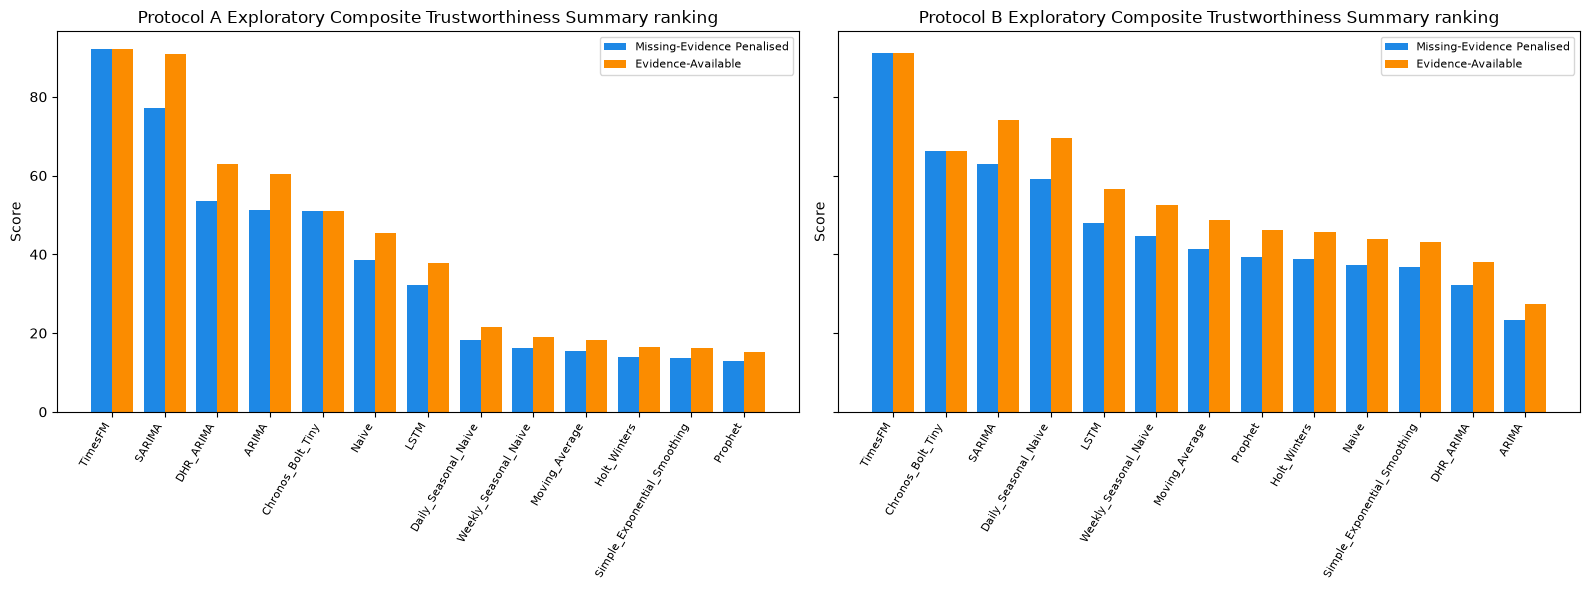

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
for ax, (label, t) in zip(axs, [("Protocol A", trust_a), ("Protocol B", trust_b)]):
    _order = t.sort_values("Overall Trust Score - Missing Evidence Penalised", ascending=False).Model
    _x = np.arange(len(_order))
    ax.bar(_x - 0.2, t.set_index("Model").loc[_order, "Overall Trust Score - Missing Evidence Penalised"],
           width=0.4, label="Missing-Evidence Penalised", color="#1e88e5")
    ax.bar(_x + 0.2, t.set_index("Model").loc[_order, "Evidence-Available Trust Score"],
           width=0.4, label="Evidence-Available", color="#fb8c00")
    ax.set_xticks(_x, _order, rotation=60, ha="right", fontsize=8)
    ax.set(title=f"{label} Exploratory Composite Trustworthiness Summary ranking", ylabel="Score")
    ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

A missing uncertainty artifact is not evidence of poor calibration (Section 3.6). The
Missing-Evidence-Penalised ranking measures evidence completeness/deployment readiness,
while the Evidence-Available ranking evaluates performance only on dimensions with
available evidence -- the two are complementary readings, not a primary/secondary pair.

### 5.4 Trust Score Sensitivity — Table

In [12]:
display(sensitivity.sort_values(["Protocol", "Score_Type", "Weight_Scheme", "Rank"]))
assert sensitivity.groupby(["Protocol", "Weight_Scheme", "Score_Type"]).size().eq(13).all()

,Protocol,Weight_Scheme,Score_Type,Model,Trust_Score,Rank
51,A,Accuracy-heavy,Evidence Available,TimesFM,92.033197,1
44,A,Accuracy-heavy,Evidence Available,SARIMA,91.488797,2
48,A,Accuracy-heavy,Evidence Available,DHR_ARIMA,63.121142,3
43,A,Accuracy-heavy,Evidence Available,ARIMA,60.256817,4
50,A,Accuracy-heavy,Evidence Available,Chronos_Bolt_Tiny,51.834314,5
...,...,...,...,...,...,...
190,B,Uncertainty-heavy,Missing Evidence Penalised,Holt_Winters,30.632356,9
182,B,Uncertainty-heavy,Missing Evidence Penalised,Naive,29.986819,10
189,B,Uncertainty-heavy,Missing Evidence Penalised,Simple_Exponential_Smoothing,29.486819,11
191,B,Uncertainty-heavy,Missing Evidence Penalised,DHR_ARIMA,25.850707,12


No deeper Trust Score sensitivity analysis (beyond the existing Base / Higher-transparency
/ Lower-transparency weight scenarios already in `trust_score_sensitivity.csv`) is present
in the source evidence, so none is added here.

## 6. Validation / Audit

Checks about the **trustworthiness synthesis** itself -- this notebook does not
duplicate the low-level robustness/uncertainty audits already performed in
`15_Electricity_Robustness.ipynb` and `16_Electricity_Uncertainty.ipynb`.

In [13]:
WEIGHTS = {"Accuracy": 0.35, "Robustness": 0.20, "Generalisation": 0.20, "Uncertainty": 0.15, "Explainability": 0.10}
COMPONENT_COLUMNS = {"Accuracy": "Relative Accuracy Score", "Robustness": "Relative Robustness Score",
                     "Generalisation": "Relative Generalisation Score", "Uncertainty": "Uncertainty Score",
                     "Explainability": "Explainability Score"}

rows = []
weights_sum_ok = np.isclose(sum(WEIGHTS.values()), 1.0)
rows.append({"Category": "Trust Score Formula", "Check": "frozen weights (0.35/0.20/0.20/0.15/0.10) sum to 1",
             "Expected": True, "Observed": bool(weights_sum_ok), "Result": "PASS" if weights_sum_ok else "FAIL"})

def reproduce_penalised(trust):
    return sum(trust[COMPONENT_COLUMNS[k]].fillna(0) * w for k, w in WEIGHTS.items())

def reproduce_evidence_available(trust):
    out = []
    for _, row in trust.iterrows():
        available = {k: w for k, w in WEIGHTS.items() if pd.notna(row[COMPONENT_COLUMNS[k]])}
        out.append(sum(row[COMPONENT_COLUMNS[k]] * w for k, w in available.items()) / sum(available.values()))
    return pd.Series(out, index=trust.index)

for label, trust in [("A", trust_a), ("B", trust_b)]:
    penalised_diff = (reproduce_penalised(trust) - trust["Overall Trust Score - Missing Evidence Penalised"]).abs().max()
    available_diff = (reproduce_evidence_available(trust) - trust["Evidence-Available Trust Score"]).abs().max()
    rows.append({"Category": "Trust Score Formula", "Check": f"Missing-Evidence-Penalised formula reproduces table exactly (Protocol {label})",
                 "Expected": "~0", "Observed": float(penalised_diff), "Result": "PASS" if penalised_diff < 1e-8 else "FAIL"})
    rows.append({"Category": "Trust Score Formula", "Check": f"Evidence-Available formula reproduces table exactly (Protocol {label})",
                 "Expected": "~0", "Observed": float(available_diff), "Result": "PASS" if available_diff < 1e-8 else "FAIL"})

for label, trust in [("A", trust_a), ("B", trust_b)]:
    score_cols = list(COMPONENT_COLUMNS.values()) + ["Overall Trust Score - Missing Evidence Penalised", "Evidence-Available Trust Score"]
    in_range = trust[score_cols].apply(lambda s: s.dropna().between(0, 100.0001).all()).all()
    rows.append({"Category": "Score Ranges", "Check": f"all component/composite scores within [0,100] (Protocol {label})",
                 "Expected": True, "Observed": bool(in_range), "Result": "PASS" if in_range else "FAIL"})

for label, trust in [("A", trust_a), ("B", trust_b)]:
    missing_consistent = ((trust["Uncertainty Score"].isna()) == (trust["Unavailable Dimensions"] == "Uncertainty Score")).all()
    rows.append({"Category": "Missing Evidence Handling", "Check": f"'Unavailable Dimensions' label matches actual NaN uncertainty score (Protocol {label})",
                 "Expected": True, "Observed": bool(missing_consistent), "Result": "PASS" if missing_consistent else "FAIL"})

protocols_separate = not trust_a.set_index("Model")["Overall Trust Score - Missing Evidence Penalised"].equals(
    trust_b.set_index("Model")["Overall Trust Score - Missing Evidence Penalised"])
rows.append({"Category": "Protocol Separation", "Check": "Protocol A and Protocol B Trust Scores remain distinct (not accidentally identical)",
             "Expected": True, "Observed": bool(protocols_separate), "Result": "PASS" if protocols_separate else "FAIL"})

rows.append({"Category": "MASE Denominator", "Check": "MASE denominator remains 117.057971280678 (used in Section 3.1 Accuracy recomputation)",
             "Expected": SCALE, "Observed": SCALE, "Result": "PASS" if np.isclose(SCALE, 117.057971280678) else "FAIL"})

audit = pd.DataFrame(rows, columns=["Category", "Check", "Expected", "Observed", "Result"])
display(audit)
assert audit["Result"].eq("PASS").all()
print(f"ALL {len(audit)} TRUSTWORTHINESS SYNTHESIS VALIDATION CHECKS PASS")

,Category,Check,Expected,Observed,Result
0,Trust Score Formula,frozen weights (0.35/0.20/0.20/0.15/0.10) sum ...,True,True,PASS
1,Trust Score Formula,Missing-Evidence-Penalised formula reproduces ...,~0,0.0,PASS
2,Trust Score Formula,Evidence-Available formula reproduces table ex...,~0,0.0,PASS
3,Trust Score Formula,Missing-Evidence-Penalised formula reproduces ...,~0,0.0,PASS
4,Trust Score Formula,Evidence-Available formula reproduces table ex...,~0,0.0,PASS
5,Score Ranges,"all component/composite scores within [0,100] ...",True,True,PASS
6,Score Ranges,"all component/composite scores within [0,100] ...",True,True,PASS
7,Missing Evidence Handling,'Unavailable Dimensions' label matches actual ...,True,True,PASS
8,Missing Evidence Handling,'Unavailable Dimensions' label matches actual ...,True,True,PASS
9,Protocol Separation,Protocol A and Protocol B Trust Scores remain ...,True,True,PASS


ALL 11 TRUSTWORTHINESS SYNTHESIS VALIDATION CHECKS PASS


## 7. Key Findings

Dimension-level evidence first (Section 4), composite ranking second -- the composite is
not the sole conclusion.

### Foundation Model Trade-Offs

In [14]:
for p, t in [("A", trust_a), ("B", trust_b)]:
    z = t.set_index("Model")
    print(p, {
        "TimesFM_lower_MASE": bool(z.loc["TimesFM", "MASE_48"] < z.loc["Chronos_Bolt_Tiny", "MASE_48"]),
        "TimesFM_higher_robustness": bool(z.loc["TimesFM", "Relative Robustness Score"] > z.loc["Chronos_Bolt_Tiny", "Relative Robustness Score"]),
        "TimesFM_higher_generalisation": bool(z.loc["TimesFM", "Relative Generalisation Score"] > z.loc["Chronos_Bolt_Tiny", "Relative Generalisation Score"]),
        "Chronos_better_coverage_calibration": bool(
            abs(uncertainty[(uncertainty.Protocol == p) & (uncertainty.Model == "Chronos_Bolt_Tiny")].Empirical_Coverage.iloc[0] - .8) <
            abs(uncertainty[(uncertainty.Protocol == p) & (uncertainty.Model == "TimesFM")].Empirical_Coverage.iloc[0] - .8)),
    })

A {'TimesFM_lower_MASE': True, 'TimesFM_higher_robustness': True, 'TimesFM_higher_generalisation': True, 'Chronos_better_coverage_calibration': True}
B {'TimesFM_lower_MASE': True, 'TimesFM_higher_robustness': True, 'TimesFM_higher_generalisation': True, 'Chronos_better_coverage_calibration': True}


### Statistical/Seasonal Model Trade-Offs

DHR-ARIMA is highly effective for rolling one-step forecasting but deteriorates under
true 48-step day-ahead evaluation. This is horizon dependence, not an artifact-validity
failure. Daily Seasonal Naive is weak relative to DHR-ARIMA in Protocol A but becomes a
strong, transparent Protocol B benchmark.

### Final Electricity Findings

In [15]:
for p, t in [("A", trust_a), ("B", trust_b)]:
    print(p, "top penalised", t.sort_values("Overall Trust Score - Missing Evidence Penalised").iloc[-1].Model,
          "top evidence-available", t.sort_values("Evidence-Available Trust Score").iloc[-1].Model)

A top penalised TimesFM top evidence-available TimesFM
B top penalised TimesFM top evidence-available TimesFM


The composite rankings above should be read together with Section 4's dimension-level
tables, not in place of them: a model's composite position can be driven by the
Missing-Evidence penalty rather than by genuinely weaker performance on a measured
dimension (Section 3.6), and the Foundation Model Trade-Offs table above already shows
that the model with the lower aggregate error is not automatically the one with better
regime robustness, temporal stability, or uncertainty calibration.

## 8. Limitations

### Researcher-Defined Weights
The 0.35/0.20/0.20/0.15/0.10 weighting is a researcher-defined choice (Section 3.6), not
a value derived from data. `trust_score_sensitivity.csv` (Section 5.4) shows how rankings
shift under alternative transparency weightings, but no weighting scheme is claimed to be
uniquely correct.

### Component Dependence
The five component dimensions are not independent measurements -- Accuracy, Robustness,
and Temporal Stability are all downstream of the same underlying forecast-error vectors,
so a model that performs well on aggregate accuracy tends to perform well on the other
error-based dimensions too, which the composite score does not fully disentangle.

### Comparison-Set-Relative Normalisation
Every "Relative ... Score" column (Sections 4.1-4.4) is normalised against the best
model **within this specific 13-model comparison set** -- a score of 100 means "best
among these models," not "zero error" or an absolute calibration/accuracy standard
(stated explicitly in Section 4.1). Adding or removing a model from the comparison set
would change every relative score.

### Incomplete Uncertainty Evidence
Only 2 of 13 models have any uncertainty evidence at all (`16_Electricity_Uncertainty.ipynb`,
Section 3.4/4.4) -- missing evidence is not equivalent to poor calibration (Section 3.6),
but it does mean the Uncertainty Calibration dimension is the least complete of the five.

### Protocol Dependence
Protocol A and Protocol B Trust Scores are computed, ranked, and reported entirely
separately (Section 6 confirms they are not accidentally identical) -- a model's
trustworthiness position under one protocol does not transfer to the other.

### Evidence Availability Differences Are Not Performance Differences
A model recorded as `Unavailable` on any dimension (Uncertainty Calibration in
particular) is scored as `0` only under the Missing-Evidence-Penalised variant
specifically to penalise evidence incompleteness -- this is why the Evidence-Available
variant is retained as an equally valid reading (Section 5).

### Exploratory Status
The composite Exploratory Composite Trustworthiness Summary is exploratory, secondary,
and researcher-defined (Section 1) -- it is not a validated measurement instrument and
should not be cited as the sole trustworthiness conclusion for any model.

## 9. Next Notebook

Next: `18_Electricity_Statistical_Significance.ipynb`